# 04 - Clasificación con Transformers: DistilBERT

## Objetivo

Este notebook evalúa un enfoque basado en **Transformers** para clasificar las narrativas de reclamaciones del CFPB según la variable `Product`.

El objetivo es comparar un modelo contextual basado en **DistilBERT** con el enfoque clásico desarrollado previamente mediante **TF-IDF + Linear SVM**.

La comparación se realizará utilizando principalmente:

- **Accuracy**
- **F1-score macro**
- Precision, Recall y F1 por categoría

> Benchmark clásico obtenido previamente con el conjunto completo de entrenamiento:
>
> - Linear SVM — Accuracy: **0,8693**
> - Linear SVM — F1 macro: **0,7366**
>
> Para una comparación estrictamente controlada, este notebook también permite entrenar un Linear SVM sobre exactamente el mismo subconjunto utilizado por DistilBERT.

El primer experimento está pensado para una muestra estratificada de aproximadamente **100.000 registros**, con el objetivo de validar el enfoque Transformer antes de aumentar el volumen de datos.

In [ ]:
# Comprobar si Colab dispone de GPU
import torch

print("PyTorch:", torch.__version__)
print("GPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("AVISO: no hay GPU activa. El fine-tuning de DistilBERT será considerablemente más lento.")

PyTorch: 2.11.0+cu128
GPU disponible: True
GPU: Tesla T4


## 1. Instalación de librerías


In [ ]:
!pip -q install -U transformers datasets accelerate scikit-learn pyarrow

## 2. Importación de librerías y reproducibilidad

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Entorno preparado correctamente.")

Entorno preparado correctamente.


## 3. Carga del dataset de experimentación

In [ ]:
from google.colab import files

uploaded = files.upload()

nombre_archivo = next(iter(uploaded))
print("Archivo cargado:", nombre_archivo)

df = pd.read_csv(nombre_archivo, low_memory=False)

print("Dimensiones:", df.shape)
print("Columnas:", df.columns.tolist())

df.head()

Saving complaints_transformer_100k.csv to complaints_transformer_100k.csv
Archivo cargado: complaints_transformer_100k.csv
Dimensiones: (100000, 2)
Columnas: ['Consumer complaint narrative', 'Product']


,Consumer complaint narrative,Product
0,I am a victim of identity theft. Please delete...,Credit reporting or other personal consumer re...
1,"XXXX. Facts of the Complaint On XX/XX/year>, I...",Credit reporting or other personal consumer re...
2,Chase bank treated me horribly as being XX/XX/...,Checking or savings account
3,I do no recognize none of these inquires. Nor ...,Credit reporting or other personal consumer re...
4,"Equifax, remove XXXX XXXX from my credit repor...",Credit reporting or other personal consumer re...


## 4. Validación de los datos

Se comprueba que las variables necesarias existen y que no contienen valores nulos o vacíos antes del modelado.

In [ ]:
TEXT_COL = "Consumer complaint narrative"
TARGET_COL = "Product"

columnas_necesarias = [TEXT_COL, TARGET_COL]

faltantes = [c for c in columnas_necesarias if c not in df.columns]
if faltantes:
    raise ValueError(f"Faltan columnas necesarias: {faltantes}")

df = df[columnas_necesarias].copy()

df = df.dropna(subset=columnas_necesarias)

df = df[
    df[TEXT_COL].astype(str).str.strip().ne("") &
    df[TARGET_COL].astype(str).str.strip().ne("")
].reset_index(drop=True)

print("Dimensiones tras validación:", df.shape)
print("Número de clases:", df[TARGET_COL].nunique())

distribucion = (
    df[TARGET_COL]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

distribucion

Dimensiones tras validación: (100000, 2)
Número de clases: 11


,proportion
Product,
Credit reporting or other personal consumer reports,57.80
Debt collection,12.51
Checking or savings account,7.99
Credit card,7.49
"Money transfer, virtual currency, or money service",4.77
Mortgage,2.84
Vehicle loan or lease,2.03
Student loan,2.00
"Payday loan, title loan, personal loan, or advance loan",1.38


## 5. División en entrenamiento, validación y prueba

Se crea una división estratificada:

- **80 % entrenamiento**
- **10 % validación**
- **10 % prueba**

La validación se utiliza durante el fine-tuning para monitorizar el modelo, mientras que el conjunto de prueba se reserva para la evaluación final.

Esta separación evita utilizar el conjunto de prueba durante las decisiones de entrenamiento.

In [ ]:
X = df[TEXT_COL]
y = df[TARGET_COL]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 80000
Validation: 10000
Test: 10000


## 6. Codificación de las etiquetas

Los modelos Transformer trabajan con etiquetas numéricas. Se utiliza `LabelEncoder` para transformar los nombres de `Product` en identificadores enteros y se conservan los mapeos para interpretar posteriormente las predicciones.

In [ ]:
label_encoder = LabelEncoder()

label_encoder.fit(y_train)

y_train_enc = label_encoder.transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

num_labels = len(label_encoder.classes_)

id2label = {
    i: label
    for i, label in enumerate(label_encoder.classes_)
}

label2id = {
    label: i
    for i, label in id2label.items()
}

print("Número de clases:", num_labels)

for i, label in id2label.items():
    print(i, "->", label)

Número de clases: 11
0 -> Checking or savings account
1 -> Credit card
2 -> Credit reporting or other personal consumer reports
3 -> Debt collection
4 -> Debt or credit management
5 -> Money transfer, virtual currency, or money service
6 -> Mortgage
7 -> Payday loan, title loan, personal loan, or advance loan
8 -> Prepaid card
9 -> Student loan
10 -> Vehicle loan or lease


## 7. Conversión a Hugging Face Dataset

In [ ]:
train_df = pd.DataFrame({
    "text": X_train.reset_index(drop=True),
    "label": y_train_enc
})

val_df = pd.DataFrame({
    "text": X_val.reset_index(drop=True),
    "label": y_val_enc
})

test_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "label": y_test_enc
})

train_ds = Dataset.from_pandas(train_df, preserve_index=False)
val_ds = Dataset.from_pandas(val_df, preserve_index=False)
test_ds = Dataset.from_pandas(test_df, preserve_index=False)

print(train_ds)
print(val_ds)
print(test_ds)

Dataset({
    features: ['text', 'label'],
    num_rows: 80000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 10000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 10000
})


## 8. Tokenización con DistilBERT

DistilBERT emplea su propio **tokenizer**, que transforma el texto en tokens compatibles con el modelo preentrenado.

Se utiliza `distilbert/distilbert-base-uncased`, un modelo en inglés adecuado para las narrativas del CFPB.

Para controlar el coste computacional, en el primer experimento se limita la secuencia a **256 tokens**. Posteriormente puede evaluarse un `max_length` mayor si los resultados lo justifican.

In [ ]:
MODEL_NAME = "distilbert/distilbert-base-uncased"
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenizar(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

train_tokenized = train_ds.map(
    tokenizar,
    batched=True,
    remove_columns=["text"]
)

val_tokenized = val_ds.map(
    tokenizar,
    batched=True,
    remove_columns=["text"]
)

test_tokenized = test_ds.map(
    tokenizar,
    batched=True,
    remove_columns=["text"]
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print(train_tokenized)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/80000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 80000
})


## 9. Carga del modelo para clasificación

Se carga DistilBERT preentrenado y se añade una capa de clasificación para las categorías de `Product`.

Durante el fine-tuning, el modelo adapta sus pesos al problema específico del CFPB.

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

print("Modelo cargado correctamente.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo cargado correctamente.


## 10. Métricas de evaluación

Al igual que en el enfoque clásico, se prioriza el **F1-score macro** debido al importante desbalance entre las categorías.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )
    f1_weighted = f1_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }

## 11. Configuración del fine-tuning

La primera configuración utiliza:

- Learning rate: `2e-5`
- Batch size: `16`
- 2 épocas
- Weight decay: `0.01`
- Evaluación al final de cada época
- Selección del mejor checkpoint según **F1 macro**

Si la GPU disponible no dispone de memoria suficiente, reduce `per_device_train_batch_size` a `8`.

In [ ]:
training_args = TrainingArguments(
    output_dir="./distilbert_cfpb_results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    logging_steps=100,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer configurado correctamente.")

Trainer configurado correctamente.


## 12. Fine-tuning de DistilBERT

> Esta es la celda que inicia el entrenamiento en GPU.

En el primer experimento se recomienda ejecutar únicamente 2 épocas. Posteriormente se decidirá si tiene sentido modificar hiperparámetros o aumentar el volumen de datos.

In [ ]:
resultado_entrenamiento = trainer.train()

resultado_entrenamiento

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.460252,0.439719,0.861700,0.685158,0.858001
2,0.347515,0.420509,0.872000,0.713221,0.868945


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=10000, training_loss=0.4660739112854004, metrics={'train_runtime': 1029.1483, 'train_samples_per_second': 155.468, 'train_steps_per_second': 9.717, 'total_flos': 1.0598898204720672e+16, 'train_loss': 0.4660739112854004, 'epoch': 2.0})

## 13. Evaluación sobre el conjunto de prueba

El conjunto de prueba no se utiliza para seleccionar el modelo durante el entrenamiento. Se emplea únicamente una vez finalizado el fine-tuning.

In [ ]:
resultado_test = trainer.evaluate(
    eval_dataset=test_tokenized
)

resultado_test

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,F1 Weighted
0.347515,0.436184,2,0.866100,0.694853,0.862734


{'eval_loss': 0.43618446588516235,
 'eval_accuracy': 0.8661,
 'eval_f1_macro': 0.694852767746848,
 'eval_f1_weighted': 0.862734327393296}

## 14. Predicciones y classification report

In [ ]:
predicciones_test = trainer.predict(
    test_tokenized
)

y_pred_enc = np.argmax(
    predicciones_test.predictions,
    axis=-1
)

y_pred = label_encoder.inverse_transform(y_pred_enc)
y_test_labels = label_encoder.inverse_transform(y_test_enc)

reporte_transformer = classification_report(
    y_test_labels,
    y_pred,
    output_dict=True,
    zero_division=0
)

reporte_transformer_df = pd.DataFrame(
    reporte_transformer
).T

reporte_transformer_df.round(3)

,precision,recall,f1-score,support
Checking or savings account,0.805,0.822,0.814,799.000
Credit card,0.773,0.773,0.773,749.000
Credit reporting or other personal consumer reports,0.920,0.947,0.933,5781.000
Debt collection,0.776,0.729,0.752,1251.000
Debt or credit management,0.000,0.000,0.000,40.000
"Money transfer, virtual currency, or money service",0.816,0.790,0.803,477.000
Mortgage,0.861,0.891,0.875,284.000
"Payday loan, title loan, personal loan, or advance loan",0.562,0.493,0.525,138.000
Prepaid card,0.677,0.571,0.620,77.000
Student loan,0.859,0.825,0.842,200.000


## 15. Comparación con el enfoque clásico

Se comparan las métricas de DistilBERT con el benchmark final obtenido previamente mediante TF-IDF + Linear SVM.

> Importante: el SVM final fue entrenado sobre más de un millón de observaciones, mientras que el primer experimento Transformer utiliza una muestra menor. Por tanto, esta comparación sirve como referencia general.
>
> Para una comparación estrictamente controlada, puede entrenarse también un Linear SVM sobre exactamente la misma partición utilizada en este notebook (sección opcional 16).

In [ ]:
accuracy_distilbert = accuracy_score(
    y_test_labels,
    y_pred
)

f1_macro_distilbert = f1_score(
    y_test_labels,
    y_pred,
    average="macro",
    zero_division=0
)

comparacion_general = pd.DataFrame({
    "Modelo": [
        "TF-IDF + Linear SVM (benchmark final)",
        "DistilBERT"
    ],
    "Accuracy": [
        0.8693,
        accuracy_distilbert
    ],
    "F1 macro": [
        0.7366,
        f1_macro_distilbert
    ]
})

comparacion_general.round(4)

,Modelo,Accuracy,F1 macro
0,TF-IDF + Linear SVM (benchmark final),0.8693,0.7366
1,DistilBERT,0.8661,0.6949


## 16. Comparación controlada opcional: Linear SVM sobre la misma partición

Esta sección permite realizar una comparación estricta entre ambos enfoques utilizando exactamente los mismos registros de entrenamiento y prueba.

Puede ejecutarse después del experimento DistilBERT.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

tfidf_control = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_features=50000,
    sublinear_tf=True
)

X_train_control = tfidf_control.fit_transform(X_train)
X_test_control = tfidf_control.transform(X_test)

svm_control = LinearSVC(
    random_state=SEED
)

svm_control.fit(
    X_train_control,
    y_train
)

y_pred_svm_control = svm_control.predict(
    X_test_control
)

accuracy_svm_control = accuracy_score(
    y_test,
    y_pred_svm_control
)

f1_macro_svm_control = f1_score(
    y_test,
    y_pred_svm_control,
    average="macro",
    zero_division=0
)

comparacion_controlada = pd.DataFrame({
    "Modelo": [
        "TF-IDF + Linear SVM",
        "DistilBERT"
    ],
    "Accuracy": [
        accuracy_svm_control,
        accuracy_distilbert
    ],
    "F1 macro": [
        f1_macro_svm_control,
        f1_macro_distilbert
    ]
})

comparacion_controlada.round(4)

,Modelo,Accuracy,F1 macro
0,TF-IDF + Linear SVM,0.8528,0.7012
1,DistilBERT,0.8661,0.6949


## 17. Análisis de una categoría difícil

En el modelado clásico, `Debt or credit management` fue la categoría más compleja, con un recall de 0,204 y un F1-score de 0,315 en el SVM final.

Se analiza específicamente su comportamiento con DistilBERT para comprobar si la representación contextual mejora su identificación.

In [ ]:
categoria_dificil = "Debt or credit management"

mask = y_test_labels == categoria_dificil

y_real_dificil = y_test_labels[mask]
y_pred_dificil = y_pred[mask]

recall_dificil = (
    (y_real_dificil == y_pred_dificil).sum()
    / len(y_real_dificil)
)

print("Casos reales:", len(y_real_dificil))
print(
    "Casos correctamente clasificados:",
    (y_real_dificil == y_pred_dificil).sum()
)
print(
    "Recall DistilBERT:",
    round(recall_dificil, 4)
)
print(
    "Recall SVM final de referencia:",
    0.204
)

Casos reales: 40
Casos correctamente clasificados: 0
Recall DistilBERT: 0.0
Recall SVM final de referencia: 0.204


## 18. Matriz de confusión normalizada

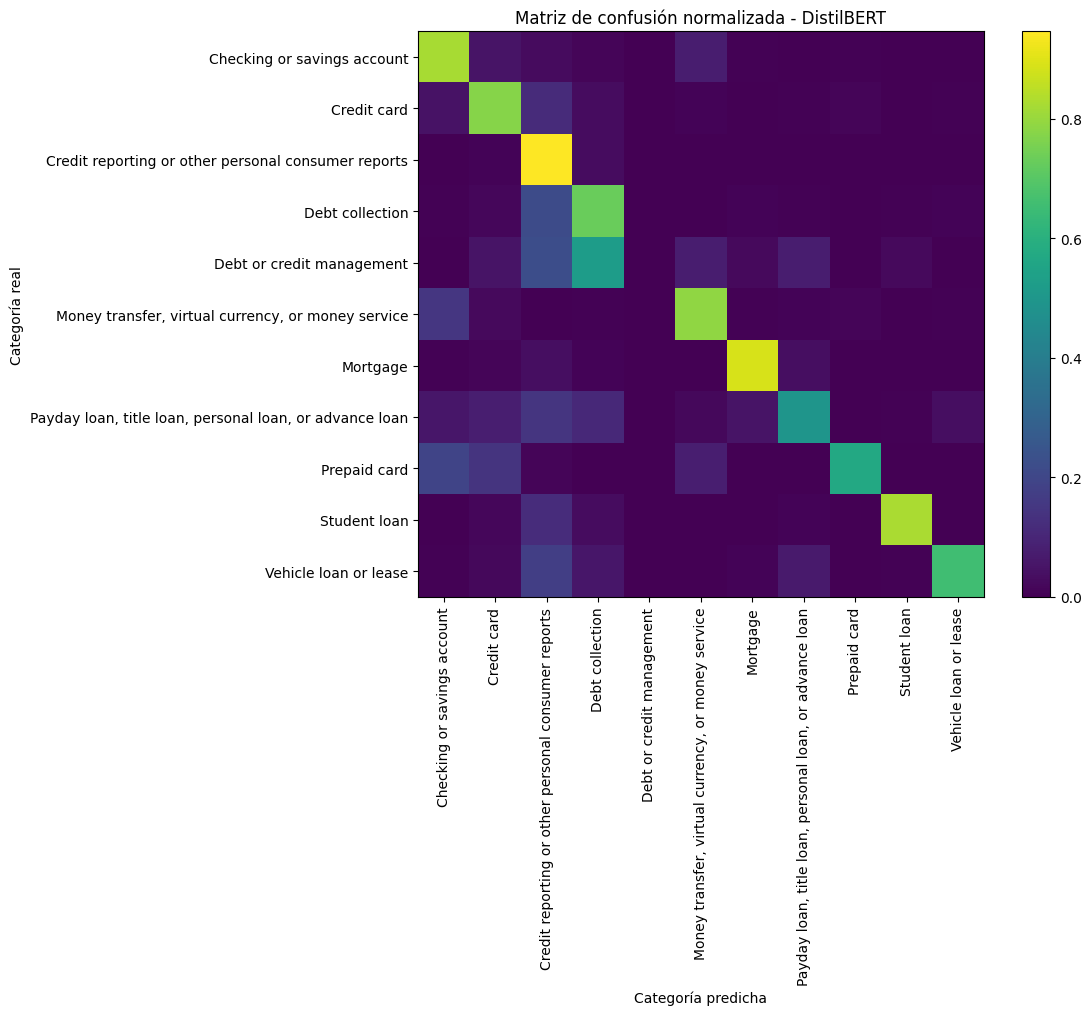

In [ ]:
import matplotlib.pyplot as plt

clases_transformer = label_encoder.classes_

cm_transformer = confusion_matrix(
    y_test_labels,
    y_pred,
    labels=clases_transformer,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(12, 10))

imagen = ax.imshow(cm_transformer)

ax.set_xticks(range(len(clases_transformer)))
ax.set_yticks(range(len(clases_transformer)))

ax.set_xticklabels(
    clases_transformer,
    rotation=90
)

ax.set_yticklabels(
    clases_transformer
)

ax.set_xlabel("Categoría predicha")
ax.set_ylabel("Categoría real")
ax.set_title("Matriz de confusión normalizada - DistilBERT")

fig.colorbar(imagen, ax=ax)

plt.tight_layout()
plt.show()

In [ ]:
# Analizar a qué categorías se asignan los casos reales
# de "Debt or credit management"

categoria_dificil = "Debt or credit management"

mask_dificil = y_test_labels == categoria_dificil

predicciones_dificil = pd.Series(
    y_pred[mask_dificil]
)

distribucion_errores = (
    predicciones_dificil
    .value_counts()
    .to_frame("Casos")
)

distribucion_errores["Porcentaje"] = (
    distribucion_errores["Casos"]
    / distribucion_errores["Casos"].sum()
    * 100
).round(2)

distribucion_errores

,Casos,Porcentaje
Debt collection,21,52.5
Credit reporting or other personal consumer reports,9,22.5
"Money transfer, virtual currency, or money service",3,7.5
"Payday loan, title loan, personal loan, or advance loan",3,7.5
Credit card,2,5.0
Mortgage,1,2.5
Student loan,1,2.5


## 19. Segundo experimento: tratamiento del desbalance mediante pesos de clase

### 19.1. Motivación del segundo experimento

El primer experimento con DistilBERT se realizó utilizando una muestra estratificada de 100.000 reclamaciones, dividida en 80.000 observaciones de entrenamiento, 10.000 de validación y 10.000 de prueba.

Tras dos épocas de fine-tuning, el modelo obtuvo sobre el conjunto de prueba:

- **Accuracy:** 0,8661
- **F1-score macro:** 0,6949
- **F1-score weighted:** 0,8627

Al comparar DistilBERT con Linear SVM utilizando exactamente la misma partición de datos, DistilBERT obtuvo una mayor accuracy (0,8661 frente a 0,8528), mientras que Linear SVM presentó un F1 macro ligeramente superior (0,7012 frente a 0,6949).

El análisis por categorías mostró que el principal problema de DistilBERT se encontraba en las clases con menor representación. En particular, la categoría `Debt or credit management`, que representa aproximadamente el 0,41 % del conjunto de datos, obtuvo un **recall de 0,000 y un F1-score de 0,000**. De los 40 casos de esta categoría presentes en el conjunto de prueba, ninguno fue clasificado correctamente.

El análisis de los errores mostró además que:

- el 52,5 % fue clasificado como `Debt collection`;
- el 22,5 % como `Credit reporting or other personal consumer reports`;
- el 25 % restante se distribuyó entre otras categorías.

Por tanto, el 75 % de los casos de esta clase minoritaria se concentró principalmente en dos categorías, lo que sugiere una combinación de dos dificultades: el fuerte **desbalance entre clases** y el posible **solapamiento semántico** entre categorías relacionadas.

### 19.2. Objetivo

Antes de incrementar el tamaño del conjunto de entrenamiento, se realizará un segundo experimento manteniendo los mismos datos y la misma arquitectura DistilBERT, pero modificando la función de pérdida mediante **pesos de clase (class weights)**.

El objetivo es penalizar en mayor medida los errores cometidos sobre las categorías minoritarias y comprobar si esto permite mejorar su identificación.

Los pesos se calcularán automáticamente a partir de la frecuencia de cada categoría en el conjunto de entrenamiento. De esta forma, las clases con menor representación recibirán un peso mayor y las clases más frecuentes un peso menor.

Este experimento permitirá evaluar si es posible mejorar el **F1-score macro** y, especialmente, el recall de las categorías minoritarias, aunque esto pueda implicar una ligera reducción de la accuracy global.

Para aislar el efecto de esta modificación, se mantendrán constantes el conjunto de datos, la partición train/validation/test y los principales hiperparámetros utilizados en el primer experimento.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

clases = np.unique(y_train_enc)

pesos_clase = compute_class_weight(
    class_weight="balanced",
    classes=clases,
    y=y_train_enc
)

class_weights = torch.tensor(
    pesos_clase,
    dtype=torch.float
)

print("Pesos por clase:\n")

for i, peso in enumerate(pesos_clase):
    print(
        f"{i:2d} - {id2label[i]:70s} -> {peso:.3f}"
    )

Pesos por clase:

 0 - Checking or savings account                                            -> 1.138
 1 - Credit card                                                            -> 1.213
 2 - Credit reporting or other personal consumer reports                    -> 0.157
 3 - Debt collection                                                        -> 0.727
 4 - Debt or credit management                                              -> 22.309
 5 - Money transfer, virtual currency, or money service                     -> 1.907
 6 - Mortgage                                                               -> 3.200
 7 - Payday loan, title loan, personal loan, or advance loan                -> 6.576
 8 - Prepaid card                                                           -> 11.787
 9 - Student loan                                                           -> 4.545
10 - Vehicle loan or lease                                                  -> 4.470


In [ ]:
from torch.nn import CrossEntropyLoss

class WeightedTrainer(Trainer):

    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        weights = self.class_weights.to(logits.device)

        loss_fct = CrossEntropyLoss(weight=weights)

        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

In [ ]:
model_weighted = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

print("Nuevo modelo cargado correctamente.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Nuevo modelo cargado correctamente.


In [ ]:
training_args_weighted = TrainingArguments(
    output_dir="./distilbert_cfpb_weighted_results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    logging_steps=100,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)

trainer_weighted = WeightedTrainer(
    model=model_weighted,
    args=training_args_weighted,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=class_weights
)

print("WeightedTrainer configurado correctamente.")

WeightedTrainer configurado correctamente.


In [ ]:
resultado_entrenamiento_weighted = trainer_weighted.train()

resultado_entrenamiento_weighted

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.766361,0.898253,0.834200,0.686424,0.838784
2,0.695652,0.851847,0.844500,0.712441,0.848316


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=10000, training_loss=0.8139512084960937, metrics={'train_runtime': 1055.2331, 'train_samples_per_second': 151.625, 'train_steps_per_second': 9.477, 'total_flos': 1.0598898204720672e+16, 'train_loss': 0.8139512084960937, 'epoch': 2.0})

In [ ]:
resultado_test_weighted = trainer_weighted.evaluate(
    eval_dataset=test_tokenized
)

resultado_test_weighted

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,F1 Weighted
0.695652,0.879508,2,0.838700,0.705473,0.842705


{'eval_loss': 0.8795083165168762,
 'eval_accuracy': 0.8387,
 'eval_f1_macro': 0.7054729763322626,
 'eval_f1_weighted': 0.8427053631901619}

In [ ]:
predicciones_test_weighted = trainer_weighted.predict(
    test_tokenized
)

y_pred_weighted_enc = np.argmax(
    predicciones_test_weighted.predictions,
    axis=-1
)

y_pred_weighted = label_encoder.inverse_transform(
    y_pred_weighted_enc
)


y_test_labels = label_encoder.inverse_transform(
    y_test_enc
)

reporte_weighted = classification_report(
    y_test_labels,
    y_pred_weighted,
    output_dict=True,
    zero_division=0
)

reporte_weighted_df = pd.DataFrame(
    reporte_weighted
).T

reporte_weighted_df.round(3)

,precision,recall,f1-score,support
Checking or savings account,0.796,0.801,0.799,799.000
Credit card,0.689,0.810,0.745,749.000
Credit reporting or other personal consumer reports,0.952,0.873,0.911,5781.000
Debt collection,0.672,0.774,0.719,1251.000
Debt or credit management,0.290,0.225,0.254,40.000
"Money transfer, virtual currency, or money service",0.790,0.822,0.806,477.000
Mortgage,0.816,0.905,0.858,284.000
"Payday loan, title loan, personal loan, or advance loan",0.503,0.616,0.554,138.000
Prepaid card,0.603,0.610,0.606,77.000
Student loan,0.719,0.895,0.797,200.000


### 19.3. Resultados del modelo con pesos de clase

La incorporación de pesos de clase modificó de forma significativa el comportamiento de DistilBERT.

Sobre el conjunto de prueba, el modelo ponderado obtuvo:

- **Accuracy:** 0,8387
- **F1-score macro:** 0,7055
- **F1-score weighted:** 0,8427

En comparación con el DistilBERT estándar, la accuracy disminuyó de 0,8661 a 0,8387. Sin embargo, el F1 macro aumentó de 0,6949 a 0,7055, lo que indica una mejora en el equilibrio del rendimiento entre las diferentes categorías.

El cambio más relevante se produjo en `Debt or credit management`, la categoría con menor representación del conjunto de datos. En el modelo estándar, ninguno de los 40 casos presentes en test fue identificado correctamente, obteniendo un recall y un F1-score de 0. Con la introducción de pesos de clase, los resultados fueron:

- **Precision:** 0,290
- **Recall:** 0,225
- **F1-score:** 0,254

Por tanto, el modelo pasó de identificar correctamente 0 de los 40 casos a identificar aproximadamente 9.

También se observaron mejoras en el recall de otras categorías minoritarias. Por ejemplo, `Payday loan, title loan, personal loan, or advance loan` aumentó su recall de 0,493 a 0,616 y `Vehicle loan or lease` de 0,657 a 0,770.

Como contrapartida, el recall de la categoría mayoritaria `Credit reporting or other personal consumer reports` disminuyó de 0,947 a 0,873. Esto explica parcialmente la reducción observada en la accuracy global.

Los resultados muestran, por tanto, un **trade-off entre rendimiento global y equilibrio entre categorías**. La ponderación de clases permite al modelo prestar mayor atención a las categorías minoritarias y mejora ligeramente el F1 macro, pero a costa de una menor accuracy.

En la comparación controlada sobre el mismo conjunto de datos:

| Modelo | Accuracy | F1 macro |
|---|---:|---:|
| TF-IDF + Linear SVM | 0,8528 | 0,7012 |
| DistilBERT estándar | **0,8661** | 0,6949 |
| DistilBERT + class weights | 0,8387 | **0,7055** |

Estos resultados sugieren que el desbalance de clases constituye una limitación relevante también para los modelos Transformer. Los pesos de clase permiten corregir parcialmente este problema, aunque introducen un compromiso entre la capacidad de detectar categorías minoritarias y el rendimiento global del clasificador.

## 20. Tercer experimento: efecto del aumento del tamaño del conjunto de datos

### 20.1. Objetivo del experimento

Tras analizar el comportamiento de DistilBERT con una muestra de 100.000 observaciones y estudiar posteriormente el efecto del tratamiento del desbalance mediante pesos de clase, se plantea un tercer experimento centrado en analizar el impacto del **aumento del volumen de datos de entrenamiento**.

Para ello, se amplía la muestra estratificada de 100.000 a **250.000 reclamaciones**, manteniendo la distribución original de las 11 categorías de `Product`.

En este experimento se utilizará nuevamente **DistilBERT sin pesos de clase**, con el objetivo de aislar el efecto producido por el incremento del número de observaciones. Se mantendrán constantes los principales hiperparámetros utilizados en el primer experimento:

- Modelo: `distilbert-base-uncased`
- Longitud máxima: 256 tokens
- Learning rate: 2e-5
- Batch size de entrenamiento: 16
- Número de épocas: 2
- Weight decay: 0,01
- Métrica principal de selección: F1-score macro

La muestra de 250.000 observaciones se dividirá de forma estratificada en:

- **200.000 observaciones de entrenamiento (80 %)**
- **25.000 observaciones de validación (10 %)**
- **25.000 observaciones de prueba (10 %)**

El objetivo principal será determinar si proporcionar un mayor número de ejemplos al Transformer permite mejorar el rendimiento global y, especialmente, la identificación de las categorías minoritarias sin necesidad de modificar inicialmente la función de pérdida.

Este experimento permitirá distinguir entre dos posibles estrategias para abordar las dificultades observadas en el primer modelo: **aumentar la cantidad de datos disponibles** o **tratar explícitamente el desbalance entre clases**.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ruta_250k = "/content/drive/MyDrive/TFM/data/complaints_transformer_250k.csv"

df = pd.read_csv(
    ruta_250k,
    low_memory=False
)

print("Dimensiones:", df.shape)
print("Columnas:", df.columns.tolist())

df.head()

Dimensiones: (250000, 2)
Columnas: ['Consumer complaint narrative', 'Product']


,Consumer complaint narrative,Product
0,"This debt collector engaged in abusive, decept...",Credit reporting or other personal consumer re...
1,XXXX XXXX XXXX XXXX XXXX XXXX. XXXX XXXX XXXX ...,Credit reporting or other personal consumer re...
2,I PULLED A COPY MOST RECIENT CREDIT REPORTING ...,Credit reporting or other personal consumer re...
3,This CFPB complaint has been filed to request ...,Credit reporting or other personal consumer re...
4,Ever since my loan servicer was switched from ...,Student loan


In [ ]:
TEXT_COL = "Consumer complaint narrative"
TARGET_COL = "Product"

X = df[TEXT_COL]
y = df[TARGET_COL]

X_train_250k, X_temp_250k, y_train_250k, y_temp_250k = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

X_val_250k, X_test_250k, y_val_250k, y_test_250k = train_test_split(
    X_temp_250k,
    y_temp_250k,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp_250k
)

print("Train:", len(X_train_250k))
print("Validation:", len(X_val_250k))
print("Test:", len(X_test_250k))

Train: 200000
Validation: 25000
Test: 25000


In [ ]:
label_encoder_250k = LabelEncoder()

label_encoder_250k.fit(y_train_250k)

y_train_250k_enc = label_encoder_250k.transform(y_train_250k)
y_val_250k_enc = label_encoder_250k.transform(y_val_250k)
y_test_250k_enc = label_encoder_250k.transform(y_test_250k)

num_labels_250k = len(label_encoder_250k.classes_)

id2label_250k = {
    i: label
    for i, label in enumerate(label_encoder_250k.classes_)
}

label2id_250k = {
    label: i
    for i, label in id2label_250k.items()
}

print("Número de clases:", num_labels_250k)

for i, label in id2label_250k.items():
    print(i, "->", label)

Número de clases: 11
0 -> Checking or savings account
1 -> Credit card
2 -> Credit reporting or other personal consumer reports
3 -> Debt collection
4 -> Debt or credit management
5 -> Money transfer, virtual currency, or money service
6 -> Mortgage
7 -> Payday loan, title loan, personal loan, or advance loan
8 -> Prepaid card
9 -> Student loan
10 -> Vehicle loan or lease


In [ ]:
train_df_250k = pd.DataFrame({
    "text": X_train_250k.reset_index(drop=True),
    "label": y_train_250k_enc
})

val_df_250k = pd.DataFrame({
    "text": X_val_250k.reset_index(drop=True),
    "label": y_val_250k_enc
})

test_df_250k = pd.DataFrame({
    "text": X_test_250k.reset_index(drop=True),
    "label": y_test_250k_enc
})

train_ds_250k = Dataset.from_pandas(
    train_df_250k,
    preserve_index=False
)

val_ds_250k = Dataset.from_pandas(
    val_df_250k,
    preserve_index=False
)

test_ds_250k = Dataset.from_pandas(
    test_df_250k,
    preserve_index=False
)

print(train_ds_250k)
print(val_ds_250k)
print(test_ds_250k)

Dataset({
    features: ['text', 'label'],
    num_rows: 200000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})


In [ ]:
train_tokenized_250k = train_ds_250k.map(
    tokenizar,
    batched=True,
    remove_columns=["text"]
)

val_tokenized_250k = val_ds_250k.map(
    tokenizar,
    batched=True,
    remove_columns=["text"]
)

test_tokenized_250k = test_ds_250k.map(
    tokenizar,
    batched=True,
    remove_columns=["text"]
)

print(train_tokenized_250k)

Map:   0%|          | 0/200000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 200000
})


In [ ]:
model_250k = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels_250k,
    id2label=id2label_250k,
    label2id=label2id_250k
)

print("Modelo DistilBERT nuevo cargado para el experimento 250k.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo DistilBERT nuevo cargado para el experimento 250k.


In [ ]:
training_args_250k = TrainingArguments(
    output_dir="./distilbert_cfpb_250k_results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    logging_steps=100,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)

trainer_250k = Trainer(
    model=model_250k,
    args=training_args_250k,
    train_dataset=train_tokenized_250k,
    eval_dataset=val_tokenized_250k,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer 250k configurado correctamente.")

Trainer 250k configurado correctamente.


In [ ]:
resultado_entrenamiento_250k = trainer_250k.train()

resultado_entrenamiento_250k

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.403599,0.404284,0.870240,0.721346,0.866971
2,0.316189,0.394922,0.876680,0.747733,0.874568


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=25000, training_loss=0.4213141395568848, metrics={'train_runtime': 2592.7224, 'train_samples_per_second': 154.278, 'train_steps_per_second': 9.642, 'total_flos': 2.649742975384445e+16, 'train_loss': 0.4213141395568848, 'epoch': 2.0})

In [ ]:
resultado_test_250k = trainer_250k.evaluate(
    eval_dataset=test_tokenized_250k
)

resultado_test_250k

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,F1 Weighted
0.316189,0.403097,2,0.875520,0.752519,0.873358


{'eval_loss': 0.4030974507331848,
 'eval_accuracy': 0.87552,
 'eval_f1_macro': 0.7525191216011774,
 'eval_f1_weighted': 0.8733583989968031}

In [ ]:
predicciones_test_250k = trainer_250k.predict(
    test_tokenized_250k
)

y_pred_250k_enc = np.argmax(
    predicciones_test_250k.predictions,
    axis=-1
)

y_pred_250k = label_encoder_250k.inverse_transform(
    y_pred_250k_enc
)

y_test_250k_labels = label_encoder_250k.inverse_transform(
    y_test_250k_enc
)

reporte_250k = classification_report(
    y_test_250k_labels,
    y_pred_250k,
    output_dict=True,
    zero_division=0
)

reporte_250k_df = pd.DataFrame(
    reporte_250k
).T

reporte_250k_df.round(3)

,precision,recall,f1-score,support
Checking or savings account,0.816,0.826,0.821,1997.000
Credit card,0.819,0.762,0.790,1873.000
Credit reporting or other personal consumer reports,0.921,0.952,0.937,14451.000
Debt collection,0.799,0.747,0.772,3128.000
Debt or credit management,0.703,0.257,0.377,101.000
"Money transfer, virtual currency, or money service",0.786,0.809,0.797,1192.000
Mortgage,0.893,0.885,0.889,711.000
"Payday loan, title loan, personal loan, or advance loan",0.645,0.636,0.640,346.000
Prepaid card,0.750,0.622,0.680,193.000
Student loan,0.868,0.816,0.841,500.000


### 20.2. Resultados del aumento del volumen de datos

El tercer experimento analizó el efecto de incrementar el tamaño de la muestra utilizada para el fine-tuning de DistilBERT, pasando de 100.000 a 250.000 reclamaciones.

Para aislar el efecto del volumen de datos, se mantuvieron la arquitectura y los principales hiperparámetros utilizados en el primer experimento, sin aplicar pesos de clase. La muestra de 250.000 observaciones se dividió de forma estratificada en 200.000 casos de entrenamiento, 25.000 de validación y 25.000 de prueba.

Tras dos épocas de fine-tuning, el modelo obtuvo sobre el conjunto de prueba:

- **Accuracy:** 0,8755
- **F1-score macro:** 0,7525
- **F1-score weighted:** 0,8734

Estos resultados suponen una mejora respecto al DistilBERT estándar entrenado con 100.000 observaciones, que obtuvo una accuracy de 0,8661 y un F1 macro de 0,6949.

El incremento del volumen de datos produjo, por tanto, una mejora simultánea del rendimiento global y del equilibrio entre categorías.

Especialmente relevante fue la evolución de `Debt or credit management`, la categoría con menor representación del conjunto de datos:

| Experimento | Precision | Recall | F1-score |
|---|---:|---:|---:|
| DistilBERT 100k | 0,000 | 0,000 | 0,000 |
| DistilBERT 100k + class weights | 0,290 | 0,225 | 0,254 |
| DistilBERT 250k | **0,703** | **0,257** | **0,377** |

En el conjunto de prueba del tercer experimento existían 101 observaciones pertenecientes a esta categoría. El modelo identificó correctamente aproximadamente el 25,7 % de ellas. Aunque el recall continúa siendo reducido, la elevada precision (0,703) indica que, cuando el modelo asigna esta categoría, la predicción suele ser correcta.

El aumento del volumen de datos también permitió obtener resultados elevados en otras categorías, destacando `Credit reporting or other personal consumer reports` (F1 = 0,937), `Mortgage` (F1 = 0,889), `Student loan` (F1 = 0,841) y `Checking or savings account` (F1 = 0,821).

### 20.3. Comparación de los experimentos con DistilBERT

| Experimento | Accuracy | F1 macro | F1 weighted |
|---|---:|---:|---:|
| DistilBERT 100k | 0,8661 | 0,6949 | 0,8627 |
| DistilBERT 100k + class weights | 0,8387 | 0,7055 | 0,8427 |
| DistilBERT 250k | **0,8755** | **0,7525** | **0,8734** |

Los resultados muestran dos estrategias diferentes frente al problema del desbalance.

La incorporación de pesos de clase permitió mejorar la detección de categorías minoritarias y aumentó ligeramente el F1 macro, aunque a costa de una reducción de la accuracy global. Por el contrario, el aumento del volumen de datos permitió mejorar simultáneamente la accuracy y el F1 macro, además de mejorar la identificación de la categoría más minoritaria.

Dentro de los experimentos realizados con Transformers, **DistilBERT entrenado con la muestra de 250.000 observaciones presenta el mejor equilibrio global**, por lo que se selecciona como modelo Transformer final.

No obstante, `Debt or credit management` continúa presentando un recall considerablemente inferior al resto de categorías. Esto indica que el incremento del volumen de datos reduce, pero no elimina completamente, las dificultades derivadas del fuerte desbalance y del posible solapamiento semántico entre categorías.

In [31]:
ruta_modelo_250k = "/content/drive/MyDrive/TFM/models/distilbert_cfpb_250k"

trainer_250k.save_model(ruta_modelo_250k)
tokenizer.save_pretrained(ruta_modelo_250k)

print("Modelo guardado correctamente en:")
print(ruta_modelo_250k)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado correctamente en:
/content/drive/MyDrive/TFM/models/distilbert_cfpb_250k


In [32]:
import os

archivos_modelo = os.listdir(ruta_modelo_250k)

print("Archivos guardados:\n")

for archivo in archivos_modelo:
    ruta_archivo = os.path.join(ruta_modelo_250k, archivo)
    tamano_mb = os.path.getsize(ruta_archivo) / (1024 ** 2)

    print(f"{archivo:30s} {tamano_mb:.2f} MB")

Archivos guardados:

config.json                    0.00 MB
model.safetensors              255.45 MB
tokenizer_config.json          0.00 MB
tokenizer.json                 0.68 MB
training_args.bin              0.00 MB


Una última comprobación: cargar el modelo desde Drive. Así sabemos que lo guardado es realmente reutilizable.

In [33]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer_prueba = AutoTokenizer.from_pretrained(
    ruta_modelo_250k
)

modelo_prueba = AutoModelForSequenceClassification.from_pretrained(
    ruta_modelo_250k
)

print("Modelo recuperado correctamente.")
print("Número de clases:", modelo_prueba.config.num_labels)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Modelo recuperado correctamente.
Número de clases: 11
